## The transient Universe


### Tasks

**Remember this is a real research example, not an exam! You're welcome (and encouraged actually!) to use all the tutorials/answers/hack you find online!**


1) Read in `solutions/transient.npy`. This is a (100 x 3) numpy array, containing some time-series measurements from a transient phenomenon. The first column is time (arbitrary units), the second column is the flux (arbitrary units), and the third column are homoescedastic measurement uncertainties on the flux. Plot this data with the uncertainties.

2) One possible model for this data is a sharp burst with an exponential tail rising above a nominal background level. This model can be described as:

    $y = b$, for $t<t_0$

    $y = b + A\exp[-\alpha(t-t_0)]$, for $t\geq t_0$

    where $b$ is the background amplitude, $A$ is the burst amplitude, $t_0$ is the burst epoch, and $\alpha$ encodes how rapidly the burst dies off.

    Code this burst model, and code a likelihood function for this data with the burst model. *Hint: This is similar in spirit to the likelihood when fitting polynomials to data, except now $x$ is time, and the polynomial model is now the burst model.* 





In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats
import emcee
import corner

In [2]:
def burst_model(params, time):
    b, A, t0, alpha = params

    y = np.zeros_like(time)  
    mask = time >= t0       
    y[mask] = A * np.exp(-alpha * (time[mask] - t0))

    return y + b

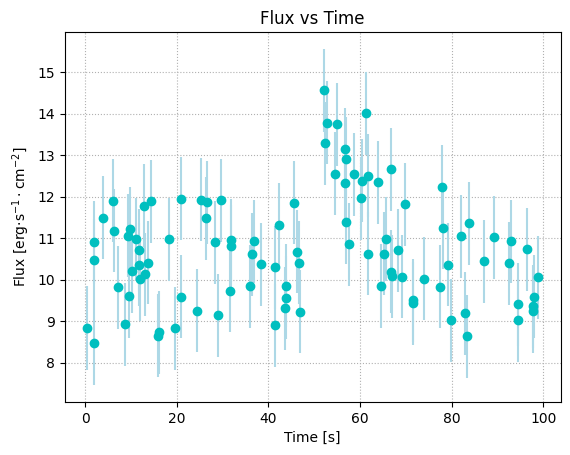

In [4]:
data = np.load("/Users/albertozanelli/Desktop/Astrostatistic2025/astrostatistics_bicocca_2025/solutions/transient.npy", allow_pickle=True)
time, flux_obs, err_flux = data[:, 0], data[:, 1], data[:, 2]

plt.errorbar(time, flux_obs, err_flux, c='c', ecolor='lightblue', fmt = "o")

plt.title("Flux vs Time")
plt.xlabel("Time [s]")
plt.ylabel(r"Flux [erg$\cdot$s$^{-1}\cdot$cm$^{-2}$]")
plt.grid(linestyle = ":")

# simple eyeballing of the INITIAL GUESSES (not prior) 
#myt=np.linspace(0,100,100)
#mym =burst_model([10,5,50,1e-1], myt)
#plt.plot(myt,mym)

plt.show()

3) Using one of the MCMC sampler that we looked at in class (`emcee`, `pymc`), perform a Bayesian analysis that recovers an MCMC chain of posterior probability samples for the joint parameter space of $\{b,A,t_0,\alpha\}$. You must decide on how many samples are appropriate for running your MCMC. For your priors, make them $b\in \mathrm{Uniform}[0,50]$, $A\in \mathrm{Uniform}[0,50]$, $t_0\in \mathrm{Uniform}[0,100]$, and $\ln\alpha\in \mathrm{Uniform}[-5,5]$ (careful: uniform in $\ln\alpha$, not $\alpha$).


In [5]:
def Log_Likelihood( params, time, flux_obs, err_flux):
    flux_model = burst_model(params, time)

    return - 0.5 * np.sum(np.log(2*np.pi*err_flux**2) + ((flux_obs - flux_model) / err_flux)**2)


def Log_Prior(params):
    b, A, t0, alpha = params
    
    if b < 0 or b > 50 or A < 0 or A > 50 or t0 < 0 or t0 > 100 or alpha < 1e-5 or alpha > 1e5: 
        return -np.inf
    else:
        return -np.log(50 * 50 * 100 * np.log(1e5/1e-5) * alpha) 


def Log_Posterior(params, time, flux_obs, err_flux):
    logPrior = Log_Prior(params)
    
    if np.isfinite(logPrior):
        return logPrior + Log_Likelihood(params, time, flux_obs, err_flux)
    else:
        return logPrior

In [6]:
n_dim = 4
n_walkers = 20
n_steps = 10000

np.random.seed(0)
starting_guesses = np.array([10,5,50,1e-1]) + 1e-2 * np.random.randn(n_walkers, n_dim)

sampler = emcee.EnsembleSampler(n_walkers, n_dim, Log_Posterior, args=[ time, flux_obs, err_flux])
sampler.run_mcmc(starting_guesses, n_steps, progress=True);

100%|██████████| 10000/10000 [00:06<00:00, 1547.46it/s]


4) Perform an appropriate check to burn-in your chain, and thin the chain by selecting only points every auto-correlation length. If you are left with a small number of samples after thinning then you may need to run your MCMC for longer in (3).

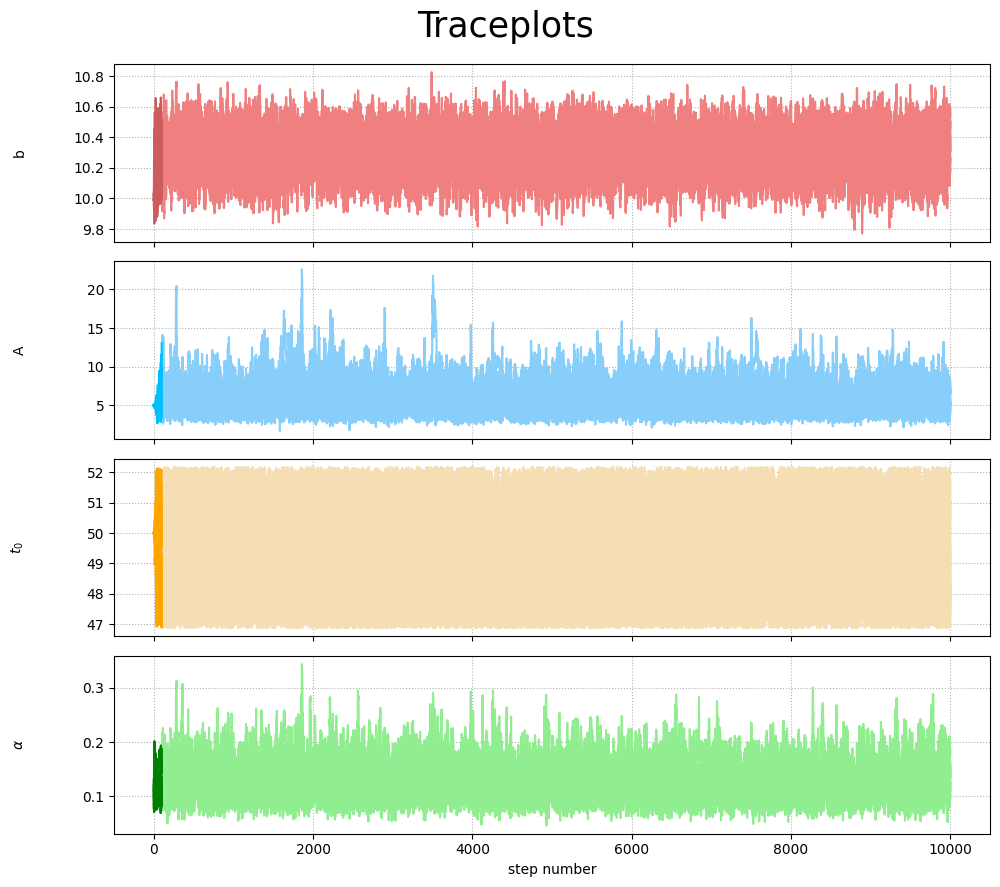

In [7]:
samples = sampler.get_chain() # sampler.chain is of shape (nwalkers, nsteps, ndim)

labels = ["b", "A", r"$t_0$", r"$\alpha$"]
steps = np.linspace(0, n_steps, n_steps)
colors = ["lightcoral", "lightskyblue", "wheat","lightgreen" ]
dark_colors = ["indianred", "deepskyblue", "orange", "green"]

burns = [100, 100, 100, 100]

fig, axes = plt.subplots(4, figsize=(10, 9), sharex=True)
fig.suptitle("Traceplots", fontsize=25)

for i in range(0, n_dim):
    ax = axes[i]
    burn = burns[i]
    color = colors[i]
    dark_color = dark_colors[i]

    ax.plot(steps[burn:],samples[burn:, :, i], c=color)
    ax.plot(steps[:burn], samples[:burn, :, i], c=dark_color, label="Burn-in")

    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)
    #ax.set_xlim(0, 1000)
    ax.grid(linestyle=":")


axes[-1].set_xlabel("step number")

plt.tight_layout()
plt.subplots_adjust(top=0.92)  
plt.show()


5) Make a corner plot of the $4$-D parameter space, with labels, $[68,95]\%$ credible levels and quantiles, and titles.

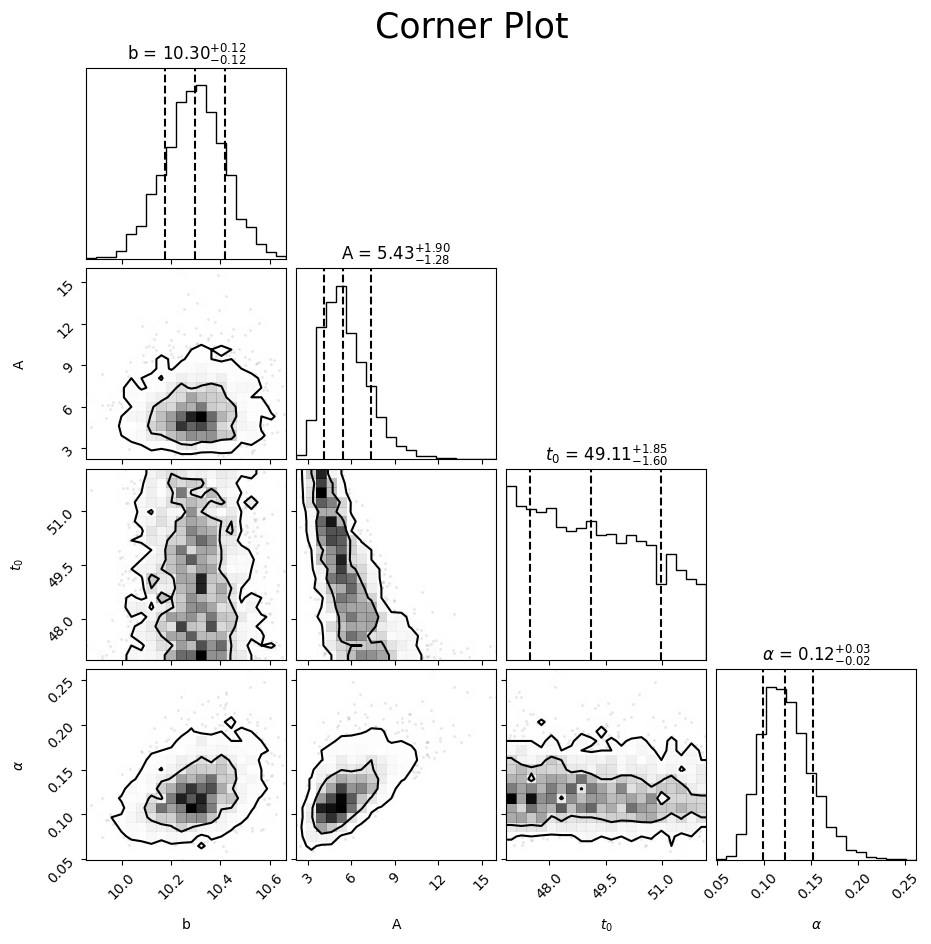

In [8]:
taus = sampler.get_autocorr_time()
burn = np.max(burns)
thin = int(np.max(taus)) + 1

emcee_traces = sampler.get_chain(discard=burn, thin=thin, flat=True)
fig = corner.corner(emcee_traces, labels=labels, show_titles=True, title_args={"fontsize": 12},
                    quantiles=[0.16, 0.5, 0.84],  
                    levels=[0.682, 0.95])
                    #range = [(9,11),(0,22),(45,55),(0.05,0.3)])
                  
fig.suptitle("Corner Plot", fontsize = 25)
plt.subplots_adjust(top=0.92)  
plt.show()


6) Now choose $100$ samples randomly from your burned, thinned chain and plot the $100$ corresponding burst time-series on a figure along with the original data. You may want to choose a transparency for these $100$ burst curves that allows you to see everything nicely. These are showing the posterior spread of model solutions that are consistent with the data.


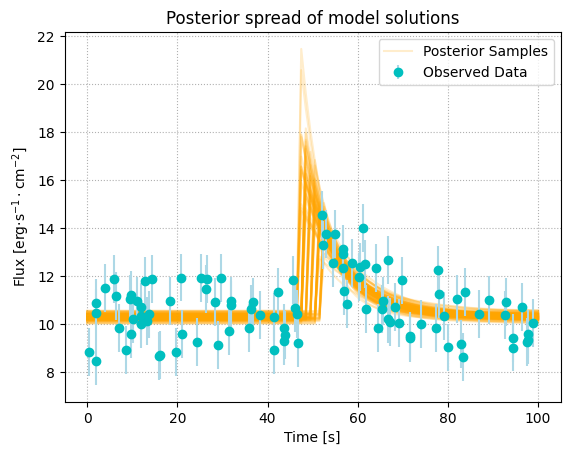

In [9]:
times_plot = np.linspace(0,100,100)

idx = np.random.choice(len(emcee_traces), size=100, replace=False)
random_samples = emcee_traces[idx]

for i, params in enumerate(random_samples):
    y_model = burst_model(params, times_plot)
    label = "Posterior Samples" if i == 0 else None
    plt.plot(times_plot, y_model, color='orange', alpha=0.2, label=label)

plt.errorbar(time, flux_obs, err_flux, c='c', ecolor='lightblue', fmt = "o", label="Observed Data")
plt.title("Posterior spread of model solutions")
plt.xlabel("Time [s]")
plt.ylabel(r"Flux [erg$\cdot$s$^{-1}\cdot$cm$^{-2}$]")
plt.grid(linestyle=":")
plt.legend()
plt.show()


7) For each parameter, find the median and 90% credible region of the marginalized distribution and quote results as, for instance, $t_0=X^{+Y}_{-Z}$ 

In [10]:
from IPython.display import display, Math, Latex

labels_output = ["b", "A", "t_0", r"\alpha"]

for i in range(n_dim):
    mcmc = np.percentile(emcee_traces[:, i], [5, 50, 95])  # median is 50 percentile
    q = np.diff(mcmc)
    txt = "\mathrm{{{3}}} = {0:.5f}_{{-{1:.5f}}}^{{{2:.5f}}}"
    txt = txt.format(mcmc[1], q[0], q[1], labels_output[i])

    display(Math(txt))

<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\m'
/var/folders/57/gp84p4410yx1sr6bqvtc5qs00000gn/T/ipykernel_83019/349099021.py:8: SyntaxWarning: invalid escape sequence '\m'
  txt = "\mathrm{{{3}}} = {0:.5f}_{{-{1:.5f}}}^{{{2:.5f}}}"


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

# The transient Universe pt.2


Let's go back to our previous example on the astrophysical transient.


8) Fit the same model from before with the same priors,  but this time use nested sampling.

$y = b$, for $t<t_0$

$y = b + A\exp[-\alpha(t-t_0)]$, for $t\geq t_0$

Be careful with how you transform your parameter space into a unit hypercube for the nested sampling priors (I used `ppf` from `scipy.stats.uniform`, but there are other ways to do it)

An appropriate check on whether you have done things correctly is that the posterior samples you get from the burst analysis here should give an equivalent corner plot to the MCMC you did earlier.

In [11]:
import dynesty
from dynesty import plotting as dyplot

In [12]:
def prior_transform(u):
    u[0:2] *= 50
    u[2] *= 100
    log_alpha = -5 + 10 * u[3] 
    u[3] = np.exp(log_alpha)

    return u


def Log_Likelihood(u):
    flux_model = burst_model(u, time)
    chi2 = ((flux_obs - flux_model) / err_flux)**2

    if np.any(chi2 > 1e15):
        return -np.inf
    
    return -0.5 * np.sum(np.log(2 * np.pi * err_flux**2) + chi2)

In [13]:
sampler = dynesty.NestedSampler(Log_Likelihood, prior_transform, n_dim, nlive=1000, bootstrap=0)
sampler.run_nested()
sresults = sampler.results

14753it [00:09, 1537.95it/s, +1000 | bound: 42 | nc: 1 | ncall: 98719 | eff(%): 16.121 | loglstar:   -inf < -140.651 <    inf | logz: -155.312 +/-  0.124 | dlogz:  0.001 >  1.009]


In [14]:
logZdynesty = sresults.logz[-1]        # value of logZ
logZerrdynesty = sresults.logzerr[-1]  # estimate of the statistcal uncertainty on logZ

print('Marginalised evidence (using static sampler) is {} ± {}'.format(logZdynesty, logZerrdynesty))

Marginalised evidence (using static sampler) is -155.31225467532548 ± 0.2837631258155603


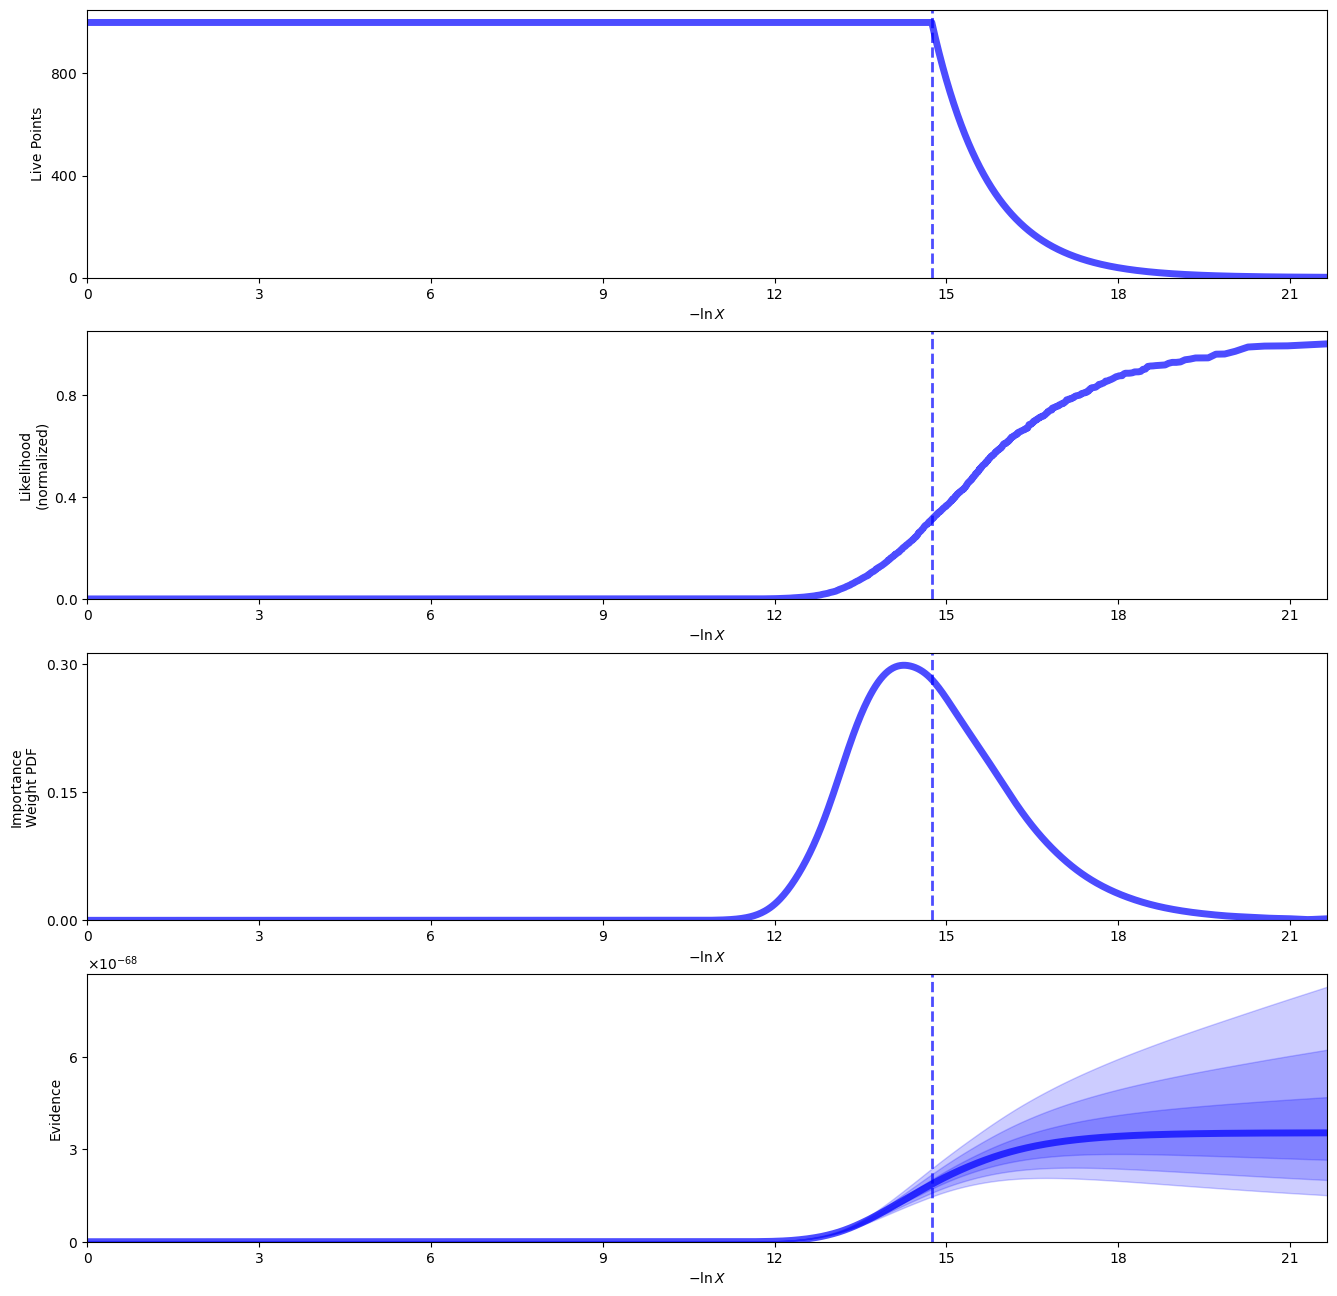

In [15]:
rfig, raxes = dyplot.runplot(sresults)

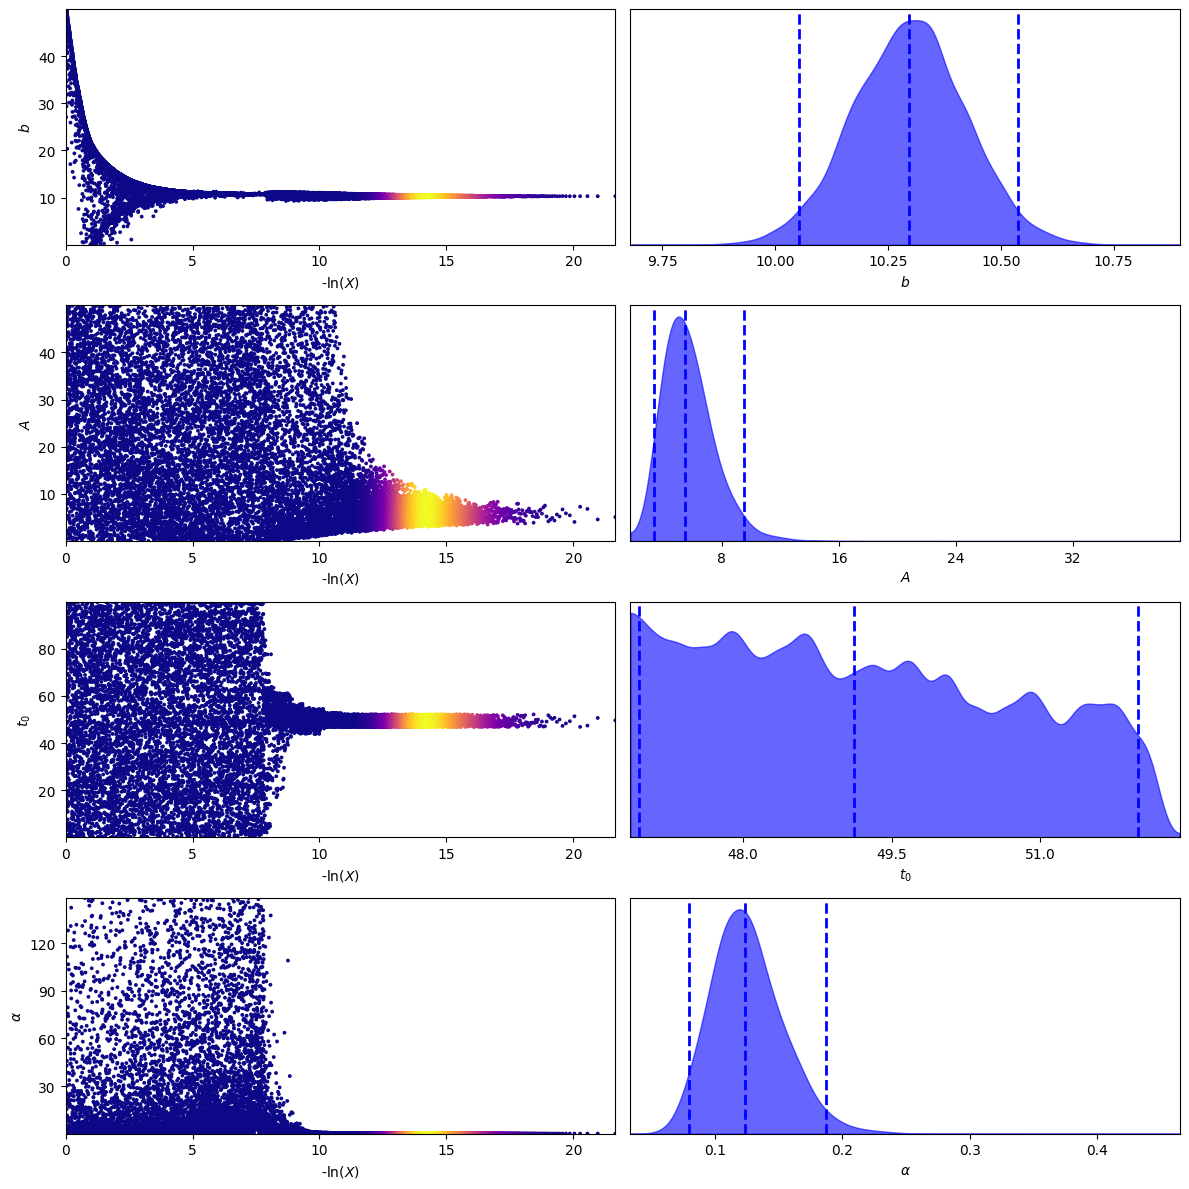

In [16]:
tfig, taxes = dyplot.traceplot(sresults)

taxes[0][0].set_xlabel("-$\\ln(X)$")
taxes[0][0].set_ylabel("$b$")
taxes[0][1].set_xlabel("$b$")


taxes[1][0].set_xlabel("-$\\ln(X)$")
taxes[1][0].set_ylabel("$A$")
taxes[1][1].set_xlabel("$A$")


taxes[2][0].set_xlabel("-$\\ln(X)$")
taxes[2][0].set_ylabel("$t_0$")
taxes[2][1].set_xlabel("$t_0$")

taxes[3][0].set_xlabel("-$\\ln(X)$")
taxes[3][0].set_ylabel(r"$\alpha$")
taxes[3][1].set_xlabel(r"$\alpha$")


tfig.tight_layout()

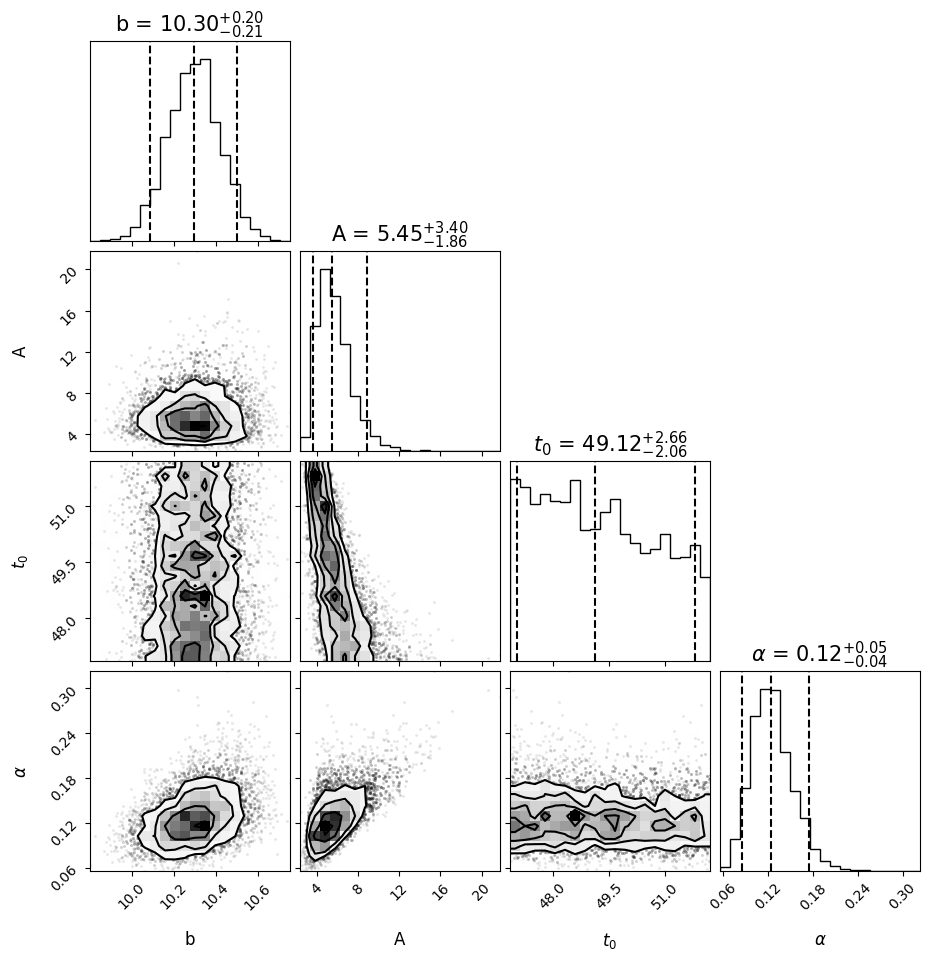

In [17]:
from dynesty.utils import resample_equal
weights = np.exp(sresults['logwt'] - sresults['logz'][-1])
postsamples = resample_equal(sresults.samples, weights)

fig = corner.corner(
    postsamples, labels=labels, quantiles=[0.05, 0.50, 0.95], show_titles=True, title_kwargs={"fontsize": 15}, label_kwargs=dict(fontsize=12)
)

In [18]:
labels_output = ["b", "A", "t_0", r"\alpha"]

for i in range(n_dim):
    mcmc = np.percentile(postsamples[:, i], [5, 50, 95])  # median is 50 percentile
    q = np.diff(mcmc)
    txt = "\mathrm{{{3}}} = {0:.5f}_{{-{1:.5f}}}^{{{2:.5f}}}"
    txt = txt.format(mcmc[1], q[0], q[1], labels_output[i])

    display(Math(txt))

<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
/var/folders/57/gp84p4410yx1sr6bqvtc5qs00000gn/T/ipykernel_83019/4147492748.py:6: SyntaxWarning: invalid escape sequence '\m'
  txt = "\mathrm{{{3}}} = {0:.5f}_{{-{1:.5f}}}^{{{2:.5f}}}"


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

9) Another possible model that may explain the data is a Gaussian profile described by:

   $y = b + A\exp[-(t-t_0)^2 / 2\sigma_W^2]$

   Fit this model usign nested sampling and reasonable priors (this time is up to you to decide...)

In [ ]:
def gauss_model(params, time):
    
    b, A, t0, sigma_w = params
    
    model = b + A * np.exp(-(time - t0)**2 / (2 * sigma_w**2))
            
    return model

def prior_transform_2(u):
    u[0:2] *= 50
    u[2] *= 100
    
    log_alpha = -4 + 8 * u[3] 
    u[3] = np.exp(log_alpha)

    return u


def Log_Likelihood_2(u):
    flux_model = gauss_model(u, time)
    chi2 = ((flux_obs - flux_model) / err_flux)**2

    if np.any(chi2 > 1e15):
        return -np.inf
    
    return -0.5 * np.sum(np.log(2 * np.pi * err_flux**2) + chi2)

In [20]:
sampler_2 = dynesty.NestedSampler(Log_Likelihood_2, prior_transform_2, n_dim, bootstrap=0)
sampler_2.run_nested()
sresults_2 = sampler_2.results

8521it [00:05, 1685.04it/s, +500 | bound: 46 | nc: 1 | ncall: 52987 | eff(%): 17.187 | loglstar:   -inf < -144.347 <    inf | logz: -160.651 +/-  0.180 | dlogz:  0.001 >  0.509]


In [21]:
logZdynesty_2 = sresults_2.logz[-1]        # value of logZ
logZerrdynesty_2 = sresults_2.logzerr[-1]  # estimate of the statistcal uncertainty on logZ

print('Marginalised evidence (using static sampler) is {} ± {}'.format(logZdynesty_2, logZerrdynesty_2))

Marginalised evidence (using static sampler) is -160.65061227224973 ± 0.30946943709597824


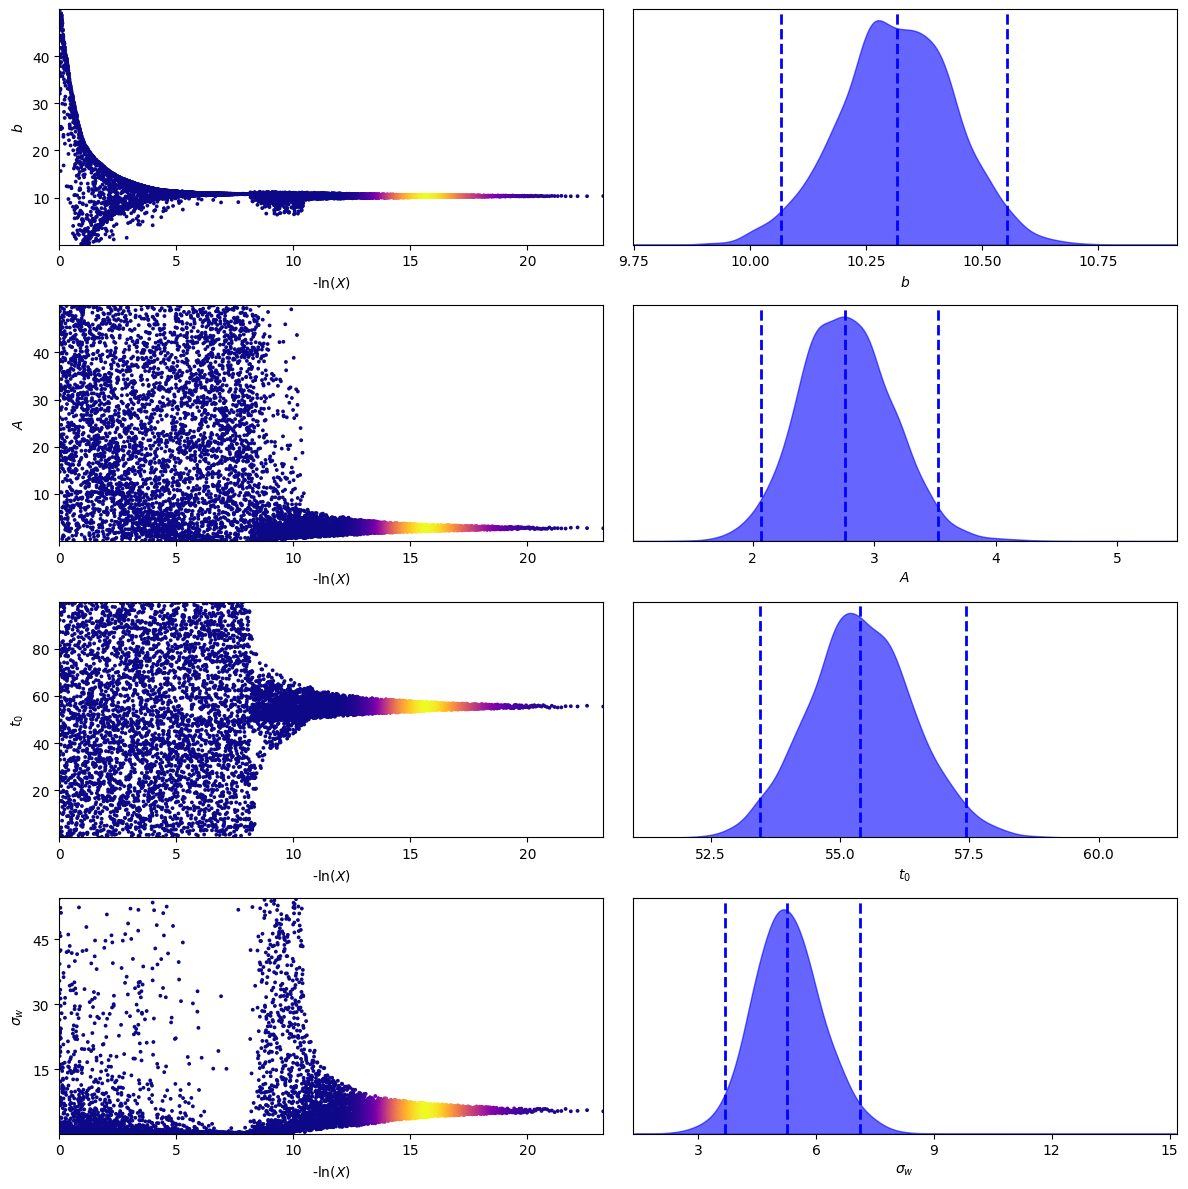

In [22]:
tfig_2, taxes_2 = dyplot.traceplot(sresults_2)

taxes_2[0][0].set_xlabel("-$\\ln(X)$")
taxes_2[0][0].set_ylabel("$b$")
taxes_2[0][1].set_xlabel("$b$")


taxes_2[1][0].set_xlabel("-$\\ln(X)$")
taxes_2[1][0].set_ylabel("$A$")
taxes_2[1][1].set_xlabel("$A$")


taxes_2[2][0].set_xlabel("-$\\ln(X)$")
taxes_2[2][0].set_ylabel("$t_0$")
taxes_2[2][1].set_xlabel("$t_0$")

taxes_2[3][0].set_xlabel("-$\\ln(X)$")
taxes_2[3][0].set_ylabel(r"$\sigma_w$")
taxes_2[3][1].set_xlabel(r"$\sigma_w$")


tfig_2.tight_layout()

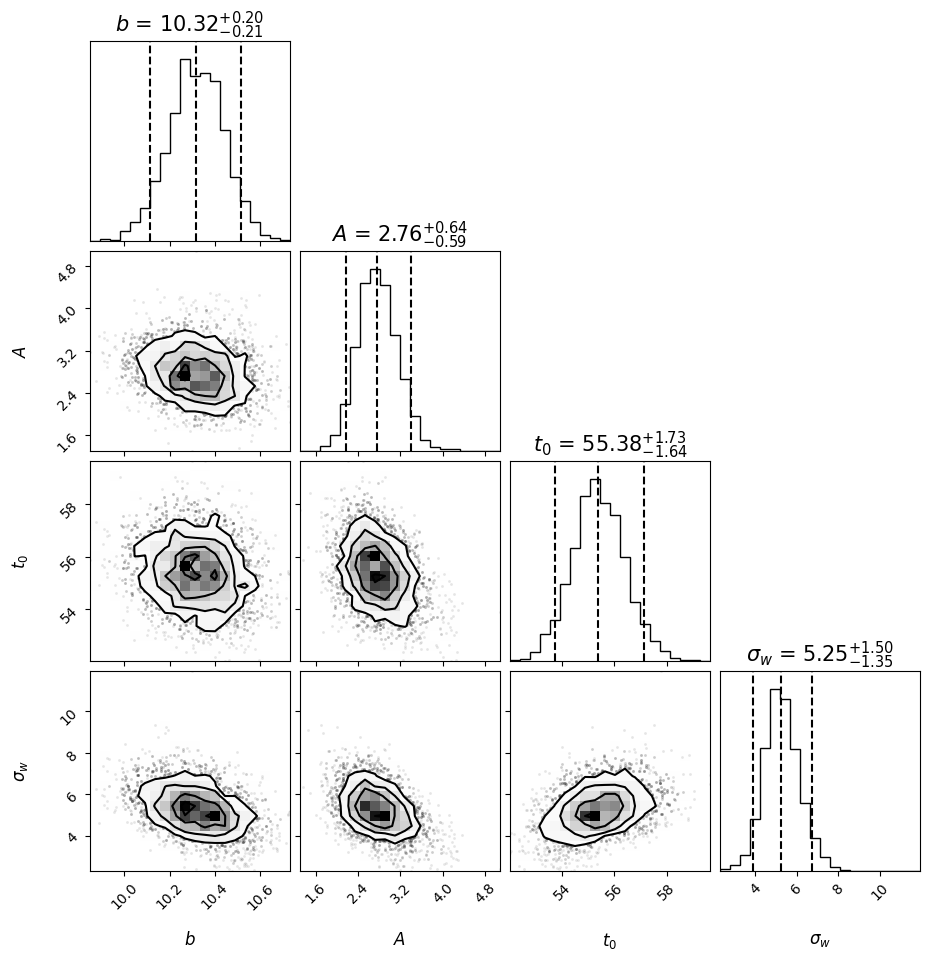

In [23]:
weights_2 = np.exp(sresults_2['logwt'] - sresults_2['logz'][-1])
postsamples_2 = resample_equal(sresults_2.samples, weights_2)

fig = corner.corner(
    postsamples_2, labels=[r"$b$", r"$A$", r"$t_0$", r"$\sigma_w$"], quantiles=[0.05, 0.5, 0.95], show_titles=True, title_kwargs={"fontsize": 15}, label_kwargs=dict(fontsize=12) 
)

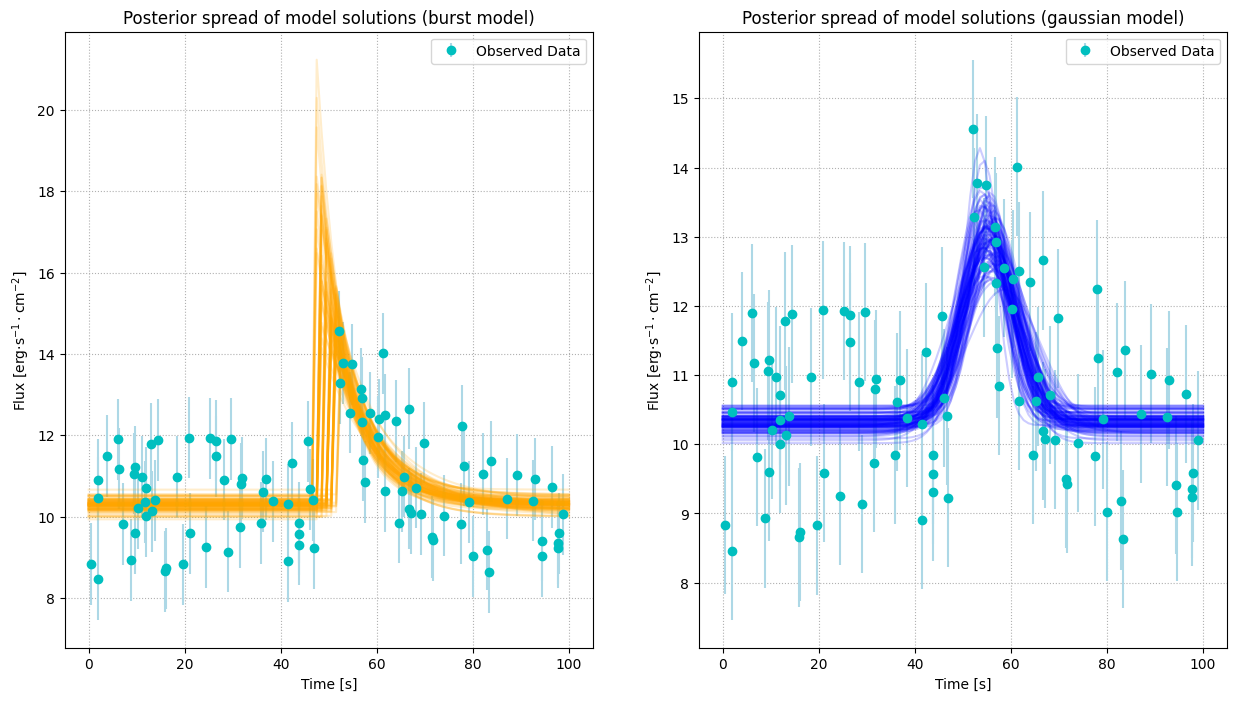

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 8))

ax1.errorbar(time, flux_obs, err_flux, c='c', ecolor='lightblue', fmt = "o", label="Observed Data")
ax1.set_title("Posterior spread of model solutions (burst model)")
ax1.set_xlabel("Time [s]")
ax1.set_ylabel(r"Flux [erg$\cdot$s$^{-1}\cdot$cm$^{-2}$]")
ax1.grid(linestyle=":")
ax1.legend()

ax2.errorbar(time, flux_obs, err_flux, c='c', ecolor='lightblue', fmt = "o", label="Observed Data")
ax2.set_title("Posterior spread of model solutions (gaussian model)")
ax2.set_xlabel("Time [s]")
ax2.set_ylabel(r"Flux [erg$\cdot$s$^{-1}\cdot$cm$^{-2}$]")
ax2.grid(linestyle=":")
ax2.legend()

for i in range(0, 100): 
    idx_burst = int(stats.uniform.rvs(0, len(postsamples)))
    y_burst_model = burst_model(postsamples[idx_burst], times_plot)

    idx_gauss = int(stats.uniform.rvs(0, len(postsamples_2)))
    y_gauss_model = gauss_model(postsamples_2[idx_gauss], times_plot)

    label = "Posterior Samples" if i == 0 else None
    ax1.plot(times_plot, y_burst_model, color='orange', alpha=0.2, label=label)
    ax2.plot(times_plot, y_gauss_model, color='blue', alpha=0.2, label=label)

10) Unlike MCMCs, nested sampling provides the Bayesian evidence. Compute the Bayesian evidence for this Gaussian model, and for the original burst model. Which model is the favored description of the data? Express this in terms of the Jeffrey's scale.

To compute the $\textit{Odds fraction}$ we use this formula: 

$$O_{1,2} = B_{1, 2} \cdot \frac{\Pi(\Theta_{1})}{\Pi(\Theta_{2})}$$

where $B_{1, 2}$ is the $\textit{Bayes factor}$ (ratio between the two evidences), $\Pi(\Theta_{1})$ and $\Pi(\Theta_{2})$ are the prior knowledge I might have on the two models. This is important when we are mostly sure about one model with respect to the other, and we test them anyway to see if model 2 provides as well a good description of data. I don't know much about the underlying process of data acquiring nor the physics beyond this type of event, so I chose to keep the prior fraction $= 1$. This way, the evidence ratio only (Bayes factor) will provide the hint on the best model.

In [25]:
B_12 = np.exp(logZdynesty) / np.exp(logZdynesty_2)
print("Bayesian factor:", B_12)

Bayesian factor: 208.1705294487368


In [26]:
# Interpretazione secondo la Jeffreys' scale
def interpret_bayes_factor(B):
    if 0 <= B < 1/2:
        return "Barely worth mentioning for Model 1"
    elif 1/2 <= B < 1:
        return "Substantial evidence for Model 1"
    elif 1 <= B < 3/2:
        return "Strong evidence for Model 1"
    elif 3/2 <= B < 2:
        return "Very strong evidence for Model 1"
    elif 2 <= B:
        return "Decisive evidence for Model 1"

interpretation = interpret_bayes_factor(np.log10(B_12))
print(f"Interpretation according to Jeffreys' scale: {interpretation}")

Interpretation according to Jeffreys' scale: Decisive evidence for Model 1


It is evident from this ratio that the burst model is better to describe data.